In [214]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

In [215]:
data = pd.read_csv("Clustering_Data.csv")
data

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740,3
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750,3
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835,3
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840,3


In [216]:
data = data.astype(float)

## Min-Max Scaling


In [217]:
data = (((data - data.min())/(data.max()- data.min()))) + 1
data

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
0,1.842105,1.191700,1.572193,1.257732,1.619565,1.627586,1.573840,1.283019,1.593060,1.372014,1.455285,1.970696,1.561341,1.0
1,1.571053,1.205534,1.417112,1.030928,1.326087,1.575862,1.510549,1.245283,1.274448,1.264505,1.463415,1.780220,1.550642,1.0
2,1.560526,1.320158,1.700535,1.412371,1.336957,1.627586,1.611814,1.320755,1.757098,1.375427,1.447154,1.695971,1.646933,1.0
3,1.878947,1.239130,1.609626,1.319588,1.467391,1.989655,1.664557,1.207547,1.558360,1.556314,1.308943,1.798535,1.857347,1.0
4,1.581579,1.365613,1.807487,1.536082,1.521739,1.627586,1.495781,1.490566,1.444795,1.259386,1.455285,1.608059,1.325963,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,1.705263,1.970356,1.582888,1.510309,1.271739,1.241379,1.056962,1.735849,1.205047,1.547782,1.130081,1.172161,1.329529,2.0
174,1.623684,1.626482,1.598930,1.639175,1.347826,1.282759,1.086498,1.566038,1.315457,1.513652,1.178862,1.106227,1.336662,2.0
175,1.589474,1.699605,1.481283,1.484536,1.543478,1.210345,1.073840,1.566038,1.296530,1.761092,1.089431,1.106227,1.397290,2.0
176,1.563158,1.365613,1.540107,1.484536,1.543478,1.231034,1.071730,1.754717,1.331230,1.684300,1.097561,1.128205,1.400856,2.0


In [218]:
# data.describe()

In [219]:
from sklearn.decomposition import PCA
from IPython.display import clear_output
def plot_clusters(data, number, centroids, i):
    pca = PCA(n_components=2)
    data_2d = pca.fit_transform(data)
    centroids_2d = pca.transform(centroids.T)
    plt.title(f"Iteration: {i}")
    clear_output(wait=True)
    plt.scatter(x=data_2d[:, 0], y=data_2d[:, 1], c=number)
    plt.scatter(x=centroids_2d[:, 0], y=centroids_2d[:, 1], marker='x', color='red')
    plt.show()
    time.sleep(1)

In [220]:
def centroid_random(df,k):
    centroids = []
    for i in range(k):
        centroid = df.apply(lambda x: float(x.sample()))
        centroids.append(centroid)
    return pd.concat(centroids, axis = 1)
    
def distance(centroids):
    return (np.sqrt(((data-centroids)**2).sum(axis = 1)))
    
def clustering_number(data,centroids):
    distances = centroids.apply(distance)
    return distances.idxmin(axis = 1),distances
    
def new_centroids(data,number,k):
    return data.groupby(number[0]).apply(lambda x: np.exp((np.log(x)+1e-10).mean())).T

In [221]:
random_centroids = centroid_random(data,3)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_18160\2001730911.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  centroid = df.apply(lambda x: float(x.sample()))


In [222]:
data

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
0,1.842105,1.191700,1.572193,1.257732,1.619565,1.627586,1.573840,1.283019,1.593060,1.372014,1.455285,1.970696,1.561341,1.0
1,1.571053,1.205534,1.417112,1.030928,1.326087,1.575862,1.510549,1.245283,1.274448,1.264505,1.463415,1.780220,1.550642,1.0
2,1.560526,1.320158,1.700535,1.412371,1.336957,1.627586,1.611814,1.320755,1.757098,1.375427,1.447154,1.695971,1.646933,1.0
3,1.878947,1.239130,1.609626,1.319588,1.467391,1.989655,1.664557,1.207547,1.558360,1.556314,1.308943,1.798535,1.857347,1.0
4,1.581579,1.365613,1.807487,1.536082,1.521739,1.627586,1.495781,1.490566,1.444795,1.259386,1.455285,1.608059,1.325963,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,1.705263,1.970356,1.582888,1.510309,1.271739,1.241379,1.056962,1.735849,1.205047,1.547782,1.130081,1.172161,1.329529,2.0
174,1.623684,1.626482,1.598930,1.639175,1.347826,1.282759,1.086498,1.566038,1.315457,1.513652,1.178862,1.106227,1.336662,2.0
175,1.589474,1.699605,1.481283,1.484536,1.543478,1.210345,1.073840,1.566038,1.296530,1.761092,1.089431,1.106227,1.397290,2.0
176,1.563158,1.365613,1.540107,1.484536,1.543478,1.231034,1.071730,1.754717,1.331230,1.684300,1.097561,1.128205,1.400856,2.0


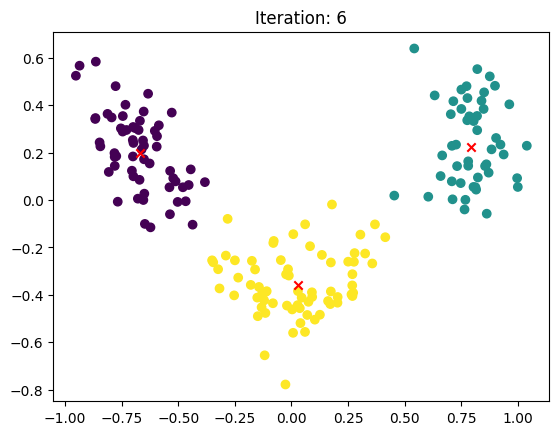

In [223]:
iterations = 100
k = 3
centroids = random_centroids
i = 1
old_centroids = pd.DataFrame()
while i<=iterations and not(centroids.equals(old_centroids)):
    old_centroids = centroids
    number,distances = clustering_number(data,centroids)
    number = pd.DataFrame(number)
    centroids = new_centroids(data,number,k)
    i += 1
    plot_clusters(data,number,centroids,i)
